In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
import pickle
from pathlib import Path
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
 
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
 
warnings.filterwarnings("ignore")

 
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120
 
MODELS_DIR = Path("saved_models")
MODELS_DIR.mkdir(exist_ok=True)
 
print("All imports successful.")

All imports successful.


In [2]:
CROP_CONFIG = {
    'Irish-potato': {'pH': {'mean': 4.68, 'std': 0.23, 'min': 4.0,  'max': 5.36}, 'N': {'mean': 100,  'std': 10,   'min': 80,  'max': 120}, 'P': {'mean': 50,   'std': 5,    'min': 40,  'max': 60},  'K': {'mean': 150,  'std': 15,   'min': 120, 'max': 180}, 'Temp': {'mean': 15,   'std': 1,    'min': 10,  'max': 20},  'Rainfall': {'mean': 500,  'std': 50,   'min': 400, 'max': 600},  'Salinity': {'mean': 0.8, 'std': 0.15, 'min': 0.3, 'max': 1.5}},
    'Tomato':       {'pH': {'mean': 6.0,  'std': 0.33, 'min': 5.0,  'max': 7.0},  'N': {'mean': 125,  'std': 8.33, 'min': 100, 'max': 150}, 'P': {'mean': 87.5, 'std': 7.5,  'min': 65,  'max': 110}, 'K': {'mean': 200,  'std': 13.3, 'min': 160, 'max': 240}, 'Temp': {'mean': 21.5, 'std': 1.17, 'min': 18,  'max': 25},  'Rainfall': {'mean': 500,  'std': 33.3, 'min': 400, 'max': 600},  'Salinity': {'mean': 1.0, 'std': 0.2,  'min': 0.5, 'max': 2.0}},
    'Groundnut':    {'pH': {'mean': 6.5,  'std': 0.17, 'min': 6.0,  'max': 7.0},  'N': {'mean': 15,   'std': 1.67, 'min': 10,  'max': 20},  'P': {'mean': 27.5, 'std': 4.17, 'min': 15,  'max': 40},  'K': {'mean': 32.5, 'std': 2.5,  'min': 25,  'max': 40},  'Temp': {'mean': 25,   'std': 1,    'min': 22,  'max': 28},  'Rainfall': {'mean': 600,  'std': 33.3, 'min': 500, 'max': 700},  'Salinity': {'mean': 0.6, 'std': 0.1,  'min': 0.2, 'max': 1.2}},
    'Pepper':       {'pH': {'mean': 6.25, 'std': 0.25, 'min': 5.5,  'max': 7.0},  'N': {'mean': 135,  'std': 11.7, 'min': 100, 'max': 170}, 'P': {'mean': 37.5, 'std': 4.17, 'min': 25,  'max': 50},  'K': {'mean': 77.5, 'std': 7.5,  'min': 55,  'max': 100}, 'Temp': {'mean': 22.5, 'std': 1.5,  'min': 18,  'max': 27},  'Rainfall': {'mean': 925,  'std': 108.3,'min': 600, 'max': 1250}, 'Salinity': {'mean': 1.2, 'std': 0.2,  'min': 0.6, 'max': 2.0}},
    'Cabbage':      {'pH': {'mean': 6.5,  'std': 0.17, 'min': 6.0,  'max': 7.0},  'N': {'mean': 125,  'std': 8.33, 'min': 100, 'max': 150}, 'P': {'mean': 57.5, 'std': 2.5,  'min': 50,  'max': 65},  'K': {'mean': 115,  'std': 5,    'min': 100, 'max': 130}, 'Temp': {'mean': 17,   'std': 2.33, 'min': 10,  'max': 24},  'Rainfall': {'mean': 440,  'std': 20,   'min': 380, 'max': 500},  'Salinity': {'mean': 0.7, 'std': 0.12, 'min': 0.2, 'max': 1.3}},
    'Maize':        {'pH': {'mean': 6.5,  'std': 0.33, 'min': 5.5,  'max': 7.5},  'N': {'mean': 175,  'std': 8.33, 'min': 150, 'max': 200}, 'P': {'mean': 65,   'std': 5,    'min': 50,  'max': 80},  'K': {'mean': 80,   'std': 6.67, 'min': 60,  'max': 100}, 'Temp': {'mean': 24,   'std': 1.33, 'min': 20,  'max': 28},  'Rainfall': {'mean': 650,  'std': 50,   'min': 500, 'max': 800},  'Salinity': {'mean': 1.0, 'std': 0.2,  'min': 0.4, 'max': 2.0}},
    'Wheat':        {'pH': {'mean': 7.0,  'std': 0.33, 'min': 6.0,  'max': 8.0},  'N': {'mean': 125,  'std': 8.33, 'min': 100, 'max': 150}, 'P': {'mean': 40,   'std': 1.67, 'min': 35,  'max': 45},  'K': {'mean': 37.5, 'std': 4.17, 'min': 25,  'max': 50},  'Temp': {'mean': 17.5, 'std': 0.83, 'min': 15,  'max': 20},  'Rainfall': {'mean': 550,  'std': 33.3, 'min': 450, 'max': 650},  'Salinity': {'mean': 1.5, 'std': 0.25, 'min': 0.8, 'max': 2.5}},
    'Pineapple':    {'pH': {'mean': 5.5,  'std': 0.33, 'min': 4.5,  'max': 6.5},  'N': {'mean': 265,  'std': 11.7, 'min': 230, 'max': 300}, 'P': {'mean': 55,   'std': 3.33, 'min': 45,  'max': 65},  'K': {'mean': 165,  'std': 18.3, 'min': 110, 'max': 220}, 'Temp': {'mean': 24,   'std': 0.67, 'min': 22,  'max': 26},  'Rainfall': {'mean': 850,  'std': 50,   'min': 700, 'max': 1000}, 'Salinity': {'mean': 0.5, 'std': 0.1,  'min': 0.1, 'max': 1.0}},
    'Onion':        {'pH': {'mean': 6.5,  'std': 0.17, 'min': 6.0,  'max': 7.0},  'N': {'mean': 80,   'std': 6.67, 'min': 60,  'max': 100}, 'P': {'mean': 35,   'std': 3.33, 'min': 25,  'max': 45},  'K': {'mean': 62.5, 'std': 5.83, 'min': 45,  'max': 80},  'Temp': {'mean': 17.5, 'std': 0.83, 'min': 15,  'max': 20},  'Rainfall': {'mean': 450,  'std': 33.3, 'min': 350, 'max': 550},  'Salinity': {'mean': 0.9, 'std': 0.15, 'min': 0.4, 'max': 1.8}},
}

UNITS = {
    'pH': 'pH scale', 'N': 'kg/ha', 'P': 'kg/ha',
    'K': 'kg/ha', 'Temp': '°C', 'Rainfall': 'mm', 'Salinity': 'dS/m'
}

features = ["N", "P", "K", "pH", "Temp", "Rainfall", "Salinity"]

print("Crop configuration loaded —", len(CROP_CONFIG), "crops defined.")


#LGA and climate zone definitions

LGAs = {
    'Barkin Ladi', 'Bassa', 'Bokkos', 'Jos East', 'Jos North', 'Jos South',
    'Kanam', 'Kanke', 'Langtang North', 'Langtang South', 'Mangu', 'Mikang',
    'Pankshin', "Qua'an-Pan", 'Riyom', 'Shendam', 'Wase'
}

HIGHLAND_LGAS = {'Bassa', 'Jos North', 'Jos South', 'Jos East',
                 'Bokkos', 'Pankshin', 'Mangu', 'Riyom'}

LGA_CLIMATE = {
    lga: 'Highland' if lga in  HIGHLAND_LGAS else 'Lowland'
    for lga in LGAs
}


# Highland has a cooler, wetter, more acidic/leached soils and lower salinity
# Lowland is warmer, drier, higher salinity (river valleys), and better nutrient retention
CLIMATE_ADJUSTMENTS = {
    'Highland': {
        'Temp': -3.0,   
        'Rainfall': +100.0, 
        'pH': -0.3,   
        'N': -10.0,  
        'P': -5.0,   
        'K': -8.0,   
        'Salinity': -0.2,   
    },
    'Lowland': {
        'Temp': +3.0,
        'Rainfall': -100.0,
        'pH': +0.3,
        'N': +10.0,
        'P': +5.0,
        'K': +8.0,
        'Salinity': +0.3,   
    }
}

# LGA-level soil "personality" and it adds a realistic inter-LGA variance so that the model doesn't see identical distributions across LGAs
# Fix seed before generating biases for reproducibility

np.random.seed(42)
LGA_SOIL_BIAS = {
    lga: {
        'pH': np.random.uniform(-0.25, 0.25),
        'N': np.random.uniform(-12, 12),
        'P': np.random.uniform(-6, 6),
        'K': np.random.uniform(-10, 10),
        'Salinity': np.random.uniform(-0.1, 0.2),
    }
    for lga in LGAs
}



Crop configuration loaded — 9 crops defined.


In [3]:
print("LGA climate zones:")
for lga, climate in LGA_CLIMATE.items():
    print(f" {lga:<18} → {climate}")
    

print(f"{len(LGAs)} LGAs configured  |  "
      f"{sum(v=='Highland' for v in LGA_CLIMATE.values())} Highland,"
       f"{sum(v=='Lowland'  for v in LGA_CLIMATE.values())} Lowland")

print("Sample bias for Jos North:", LGA_SOIL_BIAS['Jos North'])

LGA climate zones:
  Jos South          → Highland
  Kanke              → Lowland
  Qua'an-Pan         → Lowland
  Shendam            → Lowland
  Bassa              → Highland
  Barkin Ladi        → Lowland
  Bokkos             → Highland
  Riyom              → Highland
  Kanam              → Lowland
  Mikang             → Lowland
  Mangu              → Highland
  Wase               → Lowland
  Langtang North     → Lowland
  Langtang South     → Lowland
  Pankshin           → Highland
  Jos North          → Highland
  Jos East           → Highland
17 LGAs configured  |  8 Highland,9 Lowland
Sample bias for Jos North: {'pH': 0.11450358402049365, 'N': 6.510488320462699, 'P': -5.111464179190916, 'K': -2.8306854291145473, 'Salinity': -0.06523928214246108}


In [4]:
def generate_lga_data(config, lgas, n_samples=50, std_multiplier=3.5):
    
   
    rows = []
    for lga in lgas:
        climate = LGA_CLIMATE[lga]
        climate_adj = CLIMATE_ADJUSTMENTS[climate]
        lga_bias = LGA_SOIL_BIAS[lga]
 
        for crop, params in config.items():
            for _ in range(n_samples):
                row = {"LGA": lga, "Climate": climate, "Crop": crop}
 
                for param, stats in params.items():
                    mean  = stats["mean"]
                    mean += climate_adj.get(param, 0.0)   # climate zone shift
                    mean += lga_bias.get(param, 0.0)      # LGA soil personality
 
                    std = stats["std"] * std_multiplier
                    val = np.random.normal(mean, std)
                    val = np.clip(val, stats["min"] * 0.75, stats["max"] * 1.25)
                    row[param] = val
 
                rows.append(row)
 
    df = pd.DataFrame(rows)
    df = df.round({"pH": 2, "N": 2, "P": 2, "K": 2,
                   "Temp": 2, "Rainfall": 2, "Salinity": 2})
    return df

In [5]:
np.random.seed(42)
crop_data = generate_lga_data(CROP_CONFIG, LGAs, n_samples=50, std_multiplier=3.5)
 
print(f"\nDataset shape : {crop_data.shape}")
print(f"Crops: {sorted(crop_data['Crop'].unique())}")
print(f"LGAs: {crop_data['LGA'].nunique()}")
print(f"\nClass distribution:\n{crop_data['Crop'].value_counts().to_string()}")
print(f"\nClimate split:\n{crop_data['Climate'].value_counts().to_string()}")


Dataset shape  : (7650, 10)
Crops: ['Cabbage', 'Groundnut', 'Irish-potato', 'Maize', 'Onion', 'Pepper', 'Pineapple', 'Tomato', 'Wheat']
LGAs: 17

Class distribution:
Crop
Irish-potato    850
Tomato          850
Groundnut       850
Pepper          850
Cabbage         850
Maize           850
Wheat           850
Pineapple       850
Onion           850

Climate split:
Climate
Lowland     4050
Highland    3600


In [6]:
# Save
crop_data.to_csv('project_data.csv', index=False)
print("Data saved successfully as 'project_data.csv")

Data saved successfully as 'project_data.csv


In [7]:
crop_data.head()

,LGA,Climate,Crop,pH,N,P,K,Temp,Rainfall,Salinity
0,Jos South,Highland,Irish-potato,4.72,95.98,59.12,223.93,11.18,559.03,1.38
1,Jos South,Highland,Irish-potato,4.94,84.39,57.28,119.64,10.37,642.34,0.22
2,Jos South,Highland,Irish-potato,3.00,81.14,30.06,160.47,8.82,352.85,1.32
3,Jos South,Highland,Irish-potato,4.14,103.18,30.00,115.39,12.39,398.58,0.74
4,Jos South,Highland,Irish-potato,3.83,90.61,37.25,225.00,11.95,414.90,0.98


In [8]:
crop_data.info()
crop_data.describe().round(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7650 entries, 0 to 7649
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LGA       7650 non-null   object 
 1   Climate   7650 non-null   object 
 2   Crop      7650 non-null   object 
 3   pH        7650 non-null   float64
 4   N         7650 non-null   float64
 5   P         7650 non-null   float64
 6   K         7650 non-null   float64
 7   Temp      7650 non-null   float64
 8   Rainfall  7650 non-null   float64
 9   Salinity  7650 non-null   float64
dtypes: float64(7), object(3)
memory usage: 597.8+ KB


,pH,N,P,K,Temp,Rainfall,Salinity
count,7650.000,7650.000,7650.000,7650.000,7650.000,7650.000,7650.000
mean,6.210,126.612,50.763,102.905,20.658,607.890,1.037
std,1.142,70.850,22.851,63.882,6.037,245.532,0.634
min,3.000,7.500,11.250,18.750,7.500,262.500,0.080
25%,5.510,81.220,34.902,49.692,16.370,431.080,0.540
50%,6.290,120.370,48.430,90.000,20.835,567.650,0.940
75%,6.967,161.865,62.662,138.055,25.000,729.305,1.430
max,10.000,375.000,137.500,300.000,35.000,1562.500,3.120


In [9]:
crop_data.shape

(7650, 10)

In [10]:
#Step 2 EDA
crop_data.isnull().sum()

LGA         0
Climate     0
Crop        0
pH          0
N           0
P           0
K           0
Temp        0
Rainfall    0
Salinity    0
dtype: int64

In [11]:
crop_data.isnull()

,LGA,Climate,Crop,pH,N,P,K,Temp,Rainfall,Salinity
0,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
7645,False,False,False,False,False,False,False,False,False,False
7646,False,False,False,False,False,False,False,False,False,False
7647,False,False,False,False,False,False,False,False,False,False
7648,False,False,False,False,False,False,False,False,False,False


In [12]:
crop_data['Rainfall'].unique()

array([559.03, 642.34, 352.85, ..., 488.9 , 472.98, 427.88], shape=(6189,))

In [13]:
crop_data.value_counts()

LGA          Climate  Crop     pH     N       P      K       Temp   Rainfall  Salinity
Barkin Ladi  Lowland  Cabbage  5.65   167.71  59.22  96.55   15.70  359.42    1.35        1
                               5.74   136.99  68.39  101.21  27.03  332.19    1.62        1
                               6.01   114.07  50.31  127.03  10.19  332.39    0.15        1
                               6.05   106.16  69.29  162.50  7.50   325.92    1.09        1
                               6.10   151.82  65.32  113.73  13.89  316.62    0.37        1
                                                                                         ..
Wase         Lowland  Wheat    9.23   102.95  46.52  43.82   25.00  357.01    1.70        1
                               9.31   96.77   39.99  23.48   24.21  391.44    2.81        1
                               9.62   94.75   42.55  46.79   19.67  498.49    0.60        1
                               9.68   94.01   34.49  49.25   23.19  514.78    2.39   

In [14]:
crop_data.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
7645    False
7646    False
7647    False
7648    False
7649    False
Length: 7650, dtype: bool

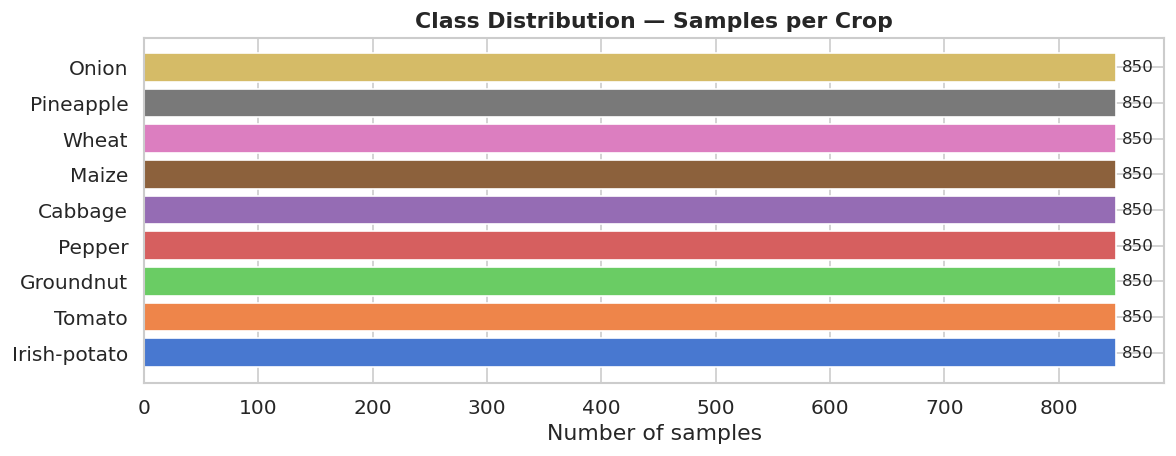

In [15]:
#class distribution
fig, ax = plt.subplots(figsize=(10, 4))
crop_counts = crop_data["Crop"].value_counts()
bars = ax.barh(
    crop_counts.index, crop_counts.values,
    color=sns.color_palette("muted", len(crop_counts))
)
for bar, val in zip(bars, crop_counts.values):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
            str(val), va="center", fontsize=10)
ax.set_xlabel("Number of samples")
ax.set_title("Class Distribution — Samples per Crop", fontweight="bold")
ax.xaxis.set_major_locator(mticker.MultipleLocator(100))
plt.tight_layout()
plt.show()

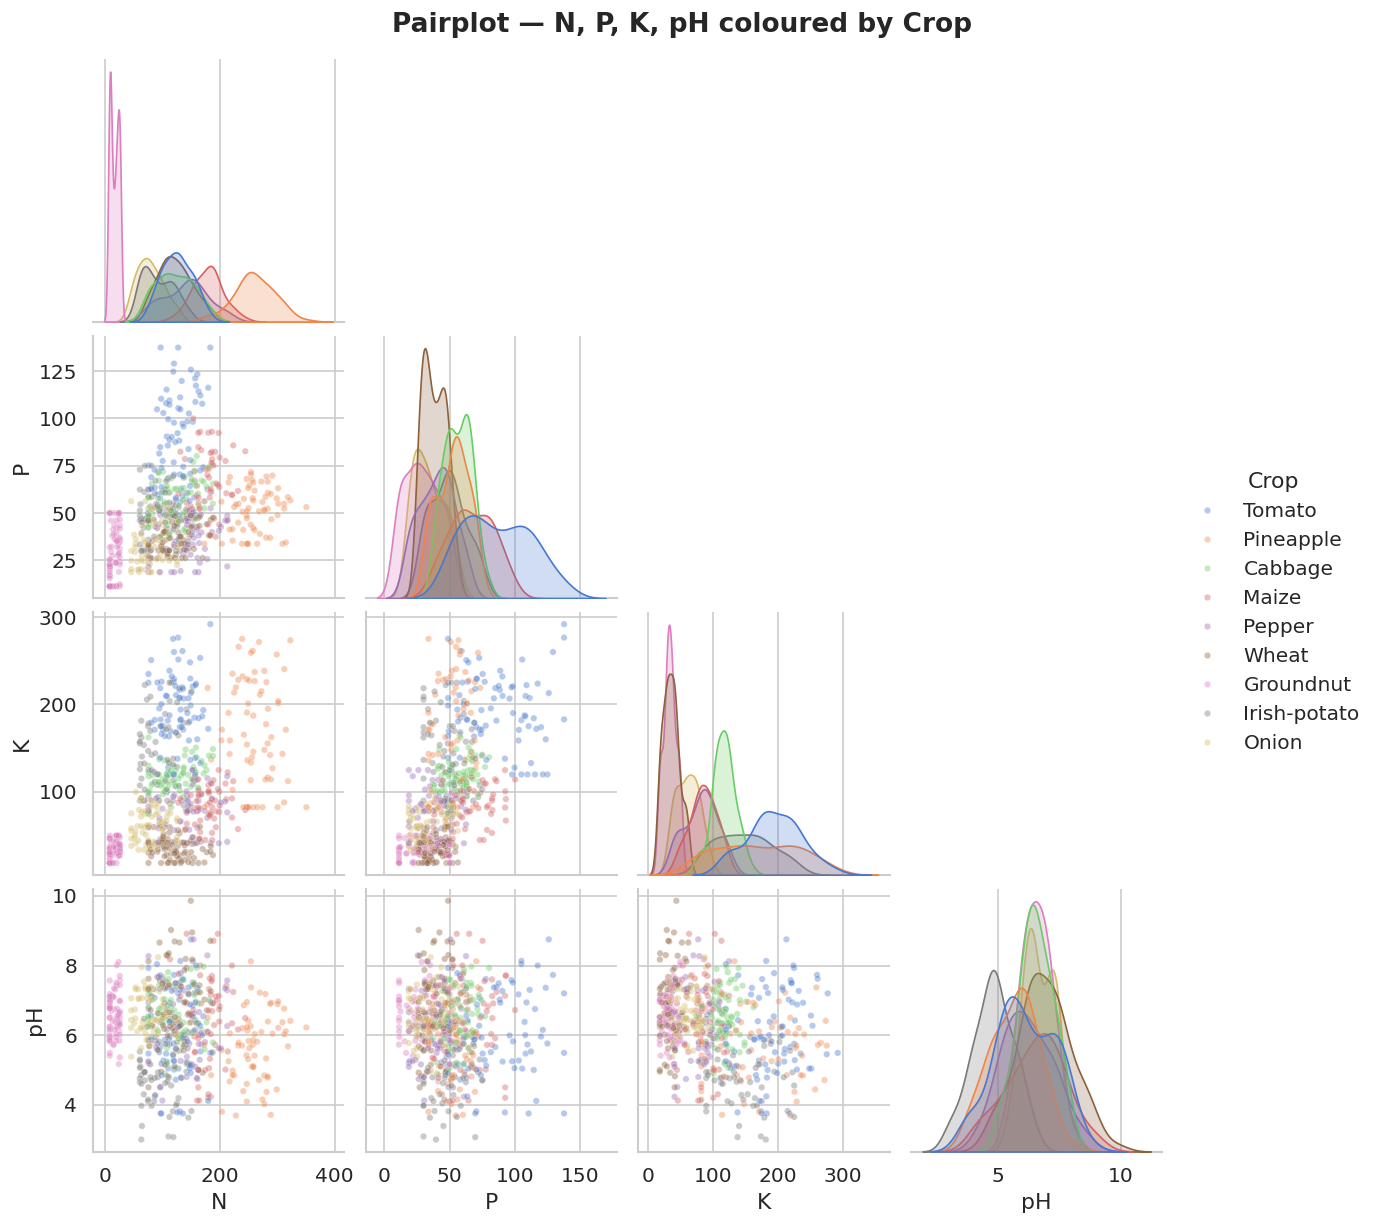

In [16]:
#Pairplot
pair_df = crop_data[["N", "P", "K", "pH", "Crop"]].sample(600, random_state=42)
g = sns.pairplot(
    pair_df, hue="Crop", vars=["N", "P", "K", "pH"],
    plot_kws={"alpha": 0.4, "s": 15},
    diag_kind="kde", corner=True,
)
g.fig.suptitle("Pairplot — N, P, K, pH coloured by Crop",
               y=1.02, fontweight="bold")
plt.show()

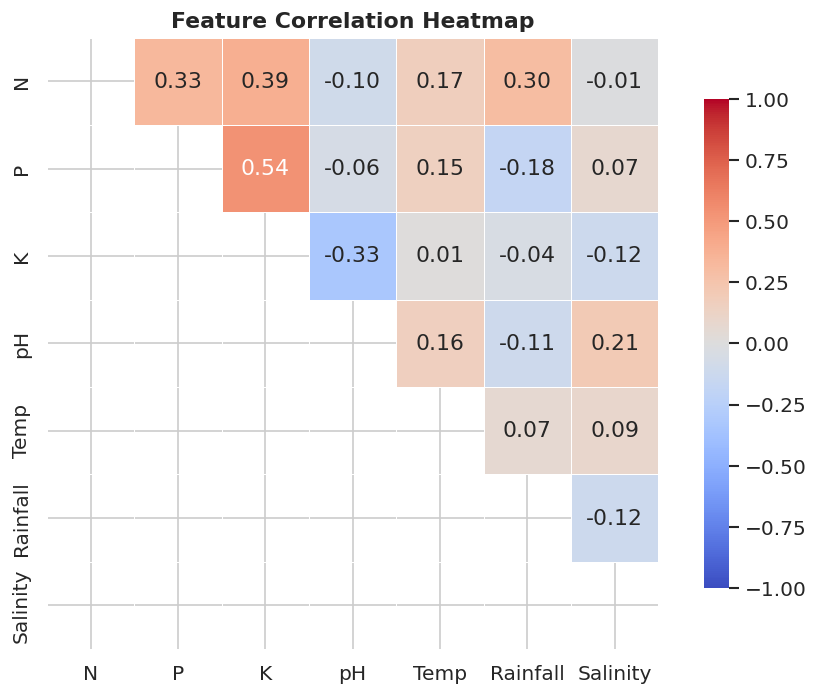

In [17]:
# Feature correlation heatmap 
corr = crop_data[features].corr()
fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
 
sns.heatmap(
    corr, mask=~mask, annot=True, fmt=".2f", cmap="coolwarm",
    vmin=-1, vmax=1, linewidths=0.5, ax=ax, square=True,
    cbar_kws={"shrink": 0.8},
)
ax.set_title("Feature Correlation Heatmap", fontweight="bold")
plt.tight_layout()
plt.show()

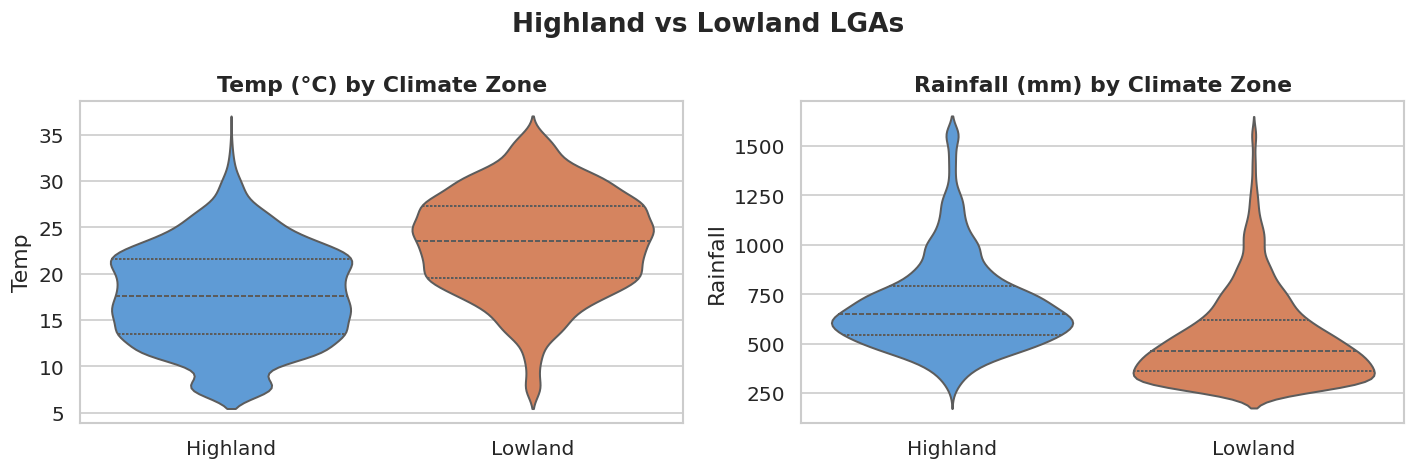

In [18]:
#Highland vs Lowland climate comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, feat in zip(axes, ["Temp", "Rainfall"]):
    sns.violinplot(
        data=crop_data, x="Climate", y=feat, ax=ax,
        palette={"Highland": "#4C9BE8", "Lowland": "#E87C4C"},
        inner="quartile", linewidth=1.2,
    )
    ax.set_title(f"{feat} ({UNITS[feat]}) by Climate Zone", fontweight="bold")
    ax.set_xlabel("")
plt.suptitle("Highland vs Lowland LGAs", fontweight="bold")
plt.tight_layout()
plt.show()

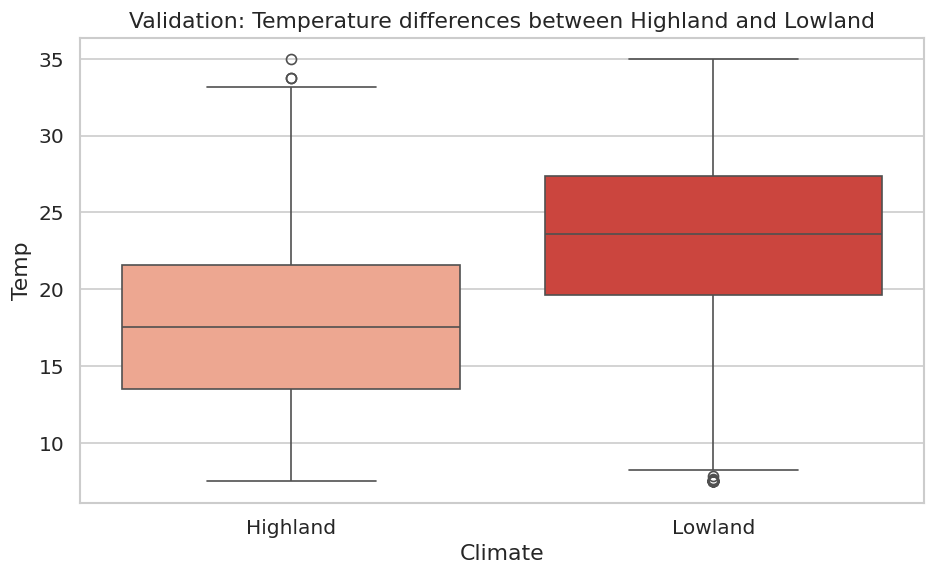

In [19]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Climate', y='Temp', data=crop_data, palette='Reds')
plt.title('Validation: Temperature differences between Highland and Lowland')
plt.tight_layout()
plt.savefig('climate_validation_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

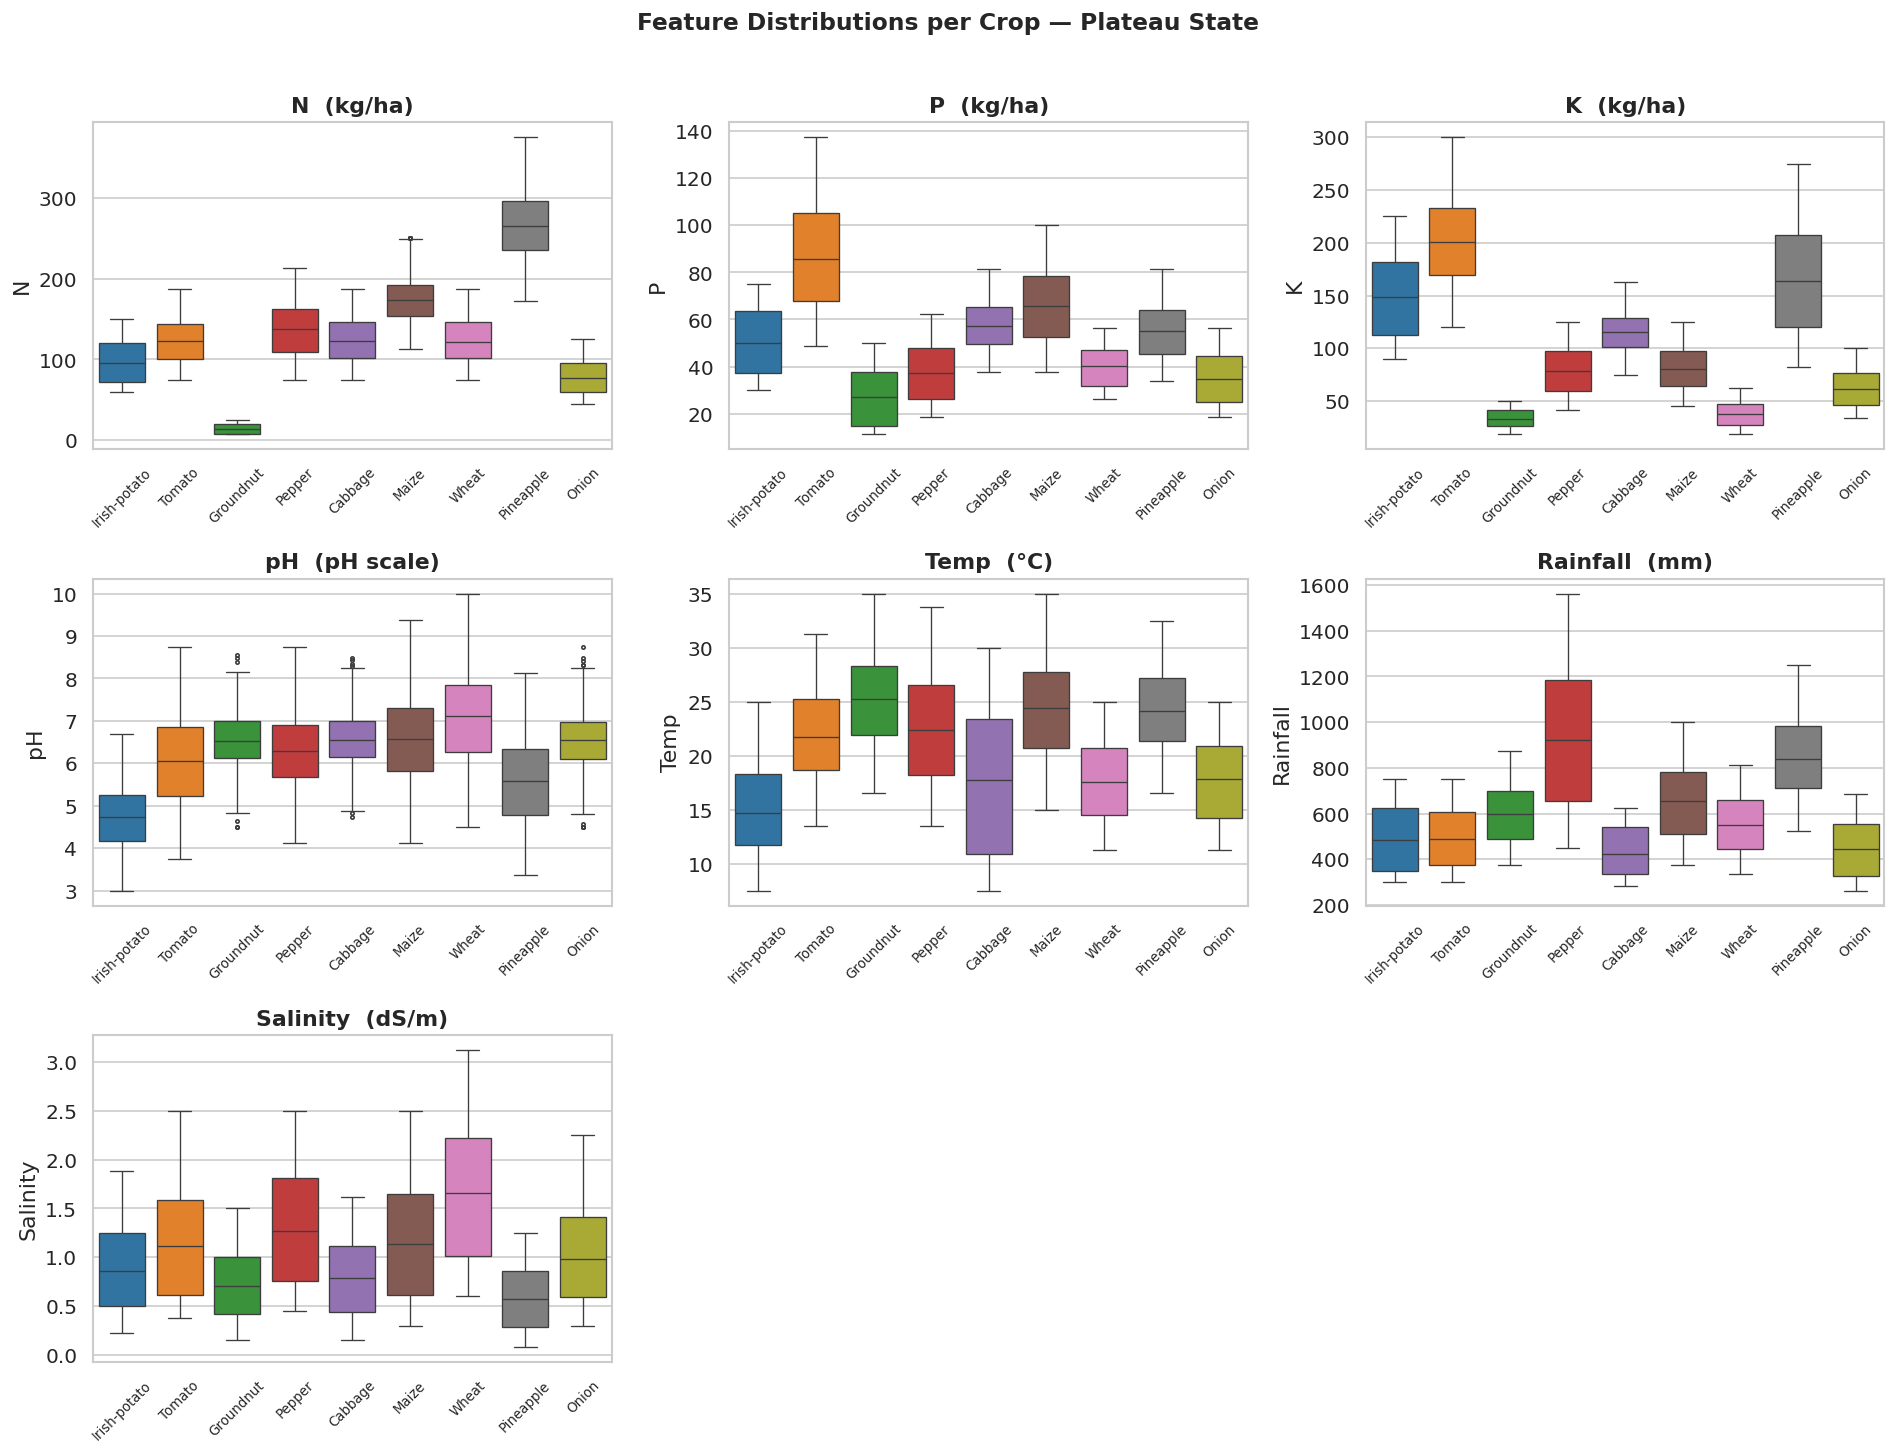

In [20]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
palette = sns.color_palette("tab10", n_colors=crop_data["Crop"].nunique())
 
for i, feat in enumerate(features):
    sns.boxplot(
        data=crop_data, x="Crop", y=feat, ax=axes[i],
        palette=palette, linewidth=0.8, fliersize=2,
    )
    axes[i].set_title(f"{feat}  ({UNITS[feat]})", fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", rotation=45, labelsize=8)
 
for j in range(len(features), len(axes)):
    axes[j].set_visible(False)
 
fig.suptitle("Feature Distributions per Crop — Plateau State",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

In [21]:
#Step3 Preprocessing
#Categorical Encoding 
CROP_LABEL_MAP = {
    "Irish-potato": 0,
    "Tomato": 1,
    "Groundnut": 2,
    "Pepper": 3,
    "Cabbage": 4,
    "Maize": 5,
    "Wheat": 6,
    "Pineapple": 7,
    "Onion": 8
}
# Reverse map — this converts the predicted integer back to a crop name at inference time
CROP_LABEL_DECODE = {v: k for k, v in CROP_LABEL_MAP.items()}
 
df = crop_data.copy()
df["Crop_encoded"] = df["Crop"].map(CROP_LABEL_MAP)
 
print("\nCrop encoding map:")
for crop, code in CROP_LABEL_MAP.items():
    print(f"  {crop:<14} → {code}")
print(f"\nNull encoded values: {df['Crop_encoded'].isna().sum()}")


Crop encoding map:
  Irish-potato   → 0
  Tomato         → 1
  Groundnut      → 2
  Pepper         → 3
  Cabbage        → 4
  Maize          → 5
  Wheat          → 6
  Pineapple      → 7
  Onion          → 8

Null encoded values: 0


In [22]:
#Feature target split
X = df[features].copy()
y = df["Crop_encoded"].copy()
 
print(f"\nX shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"Features used : {list(X.columns)}")


X shape : (7650, 7)
y shape : (7650,)
Features used : ['N', 'P', 'K', 'pH', 'Temp', 'Rainfall', 'Salinity']


In [23]:
#Step 4 Train, test and splitting
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y,        # this preserves class proportions in both splits
)
 
print(f"\nTraining set: {X_train.shape[0]} samples  "
      f"({X_train.shape[0] / len(X) * 100:.1f}%)")
print(f"Test set: {X_test.shape[0]} samples  "
      f"({X_test.shape[0] / len(X) * 100:.1f}%)")


Training set: 6120 samples  (80.0%)
Test set: 1530 samples  (20.0%)


In [24]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6120 entries, 7508 to 7060
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   N         6120 non-null   float64
 1   P         6120 non-null   float64
 2   K         6120 non-null   float64
 3   pH        6120 non-null   float64
 4   Temp      6120 non-null   float64
 5   Rainfall  6120 non-null   float64
 6   Salinity  6120 non-null   float64
dtypes: float64(7)
memory usage: 382.5 KB


In [25]:
#Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Wrap back into DataFrames to preserve column names (required by SHAP later)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=features, index=X_train.index)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=features, index=X_test.index)
 
print("\nScaling applied. Post-scale training set statistics:")
print(X_train_scaled.describe().loc[["mean", "std"]].round(4))


Scaling applied. Post-scale training set statistics:
           N       P       K      pH    Temp  Rainfall  Salinity
mean -0.0000  0.0000 -0.0000  0.0000  0.0000   -0.0000   -0.0000
std   1.0001  1.0001  1.0001  1.0001  1.0001    1.0001    1.0001


In [26]:
#Step 5 Model Training
N_CLASSES = len(CROP_LABEL_MAP)

MODELS = {
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softmax",
        num_class=N_CLASSES,
        eval_metric="mlogloss",
        random_state=42,
        verbosity=0,
    ),
    "CatBoost": CatBoostClassifier(
        iterations=300,
        depth=6,
        learning_rate=0.1,
        loss_function="MultiClass",
        random_seed=42,
        verbose=0,
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multiclass",
        num_class=N_CLASSES,
        random_state=42,
        verbose=-1,
    ),
}

results = {}  # accuracy scores
trained = {}  # fitted model objects
predictions = {}  # y_pred arrays

print("\nTraining models...")
for name, model in MODELS.items():
    print(f" {name} ...", end=" ", flush=True)
    model.fit(X_train_scaled, y_train)
 
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
 
    results[name]  = acc
    trained[name]  = model
    predictions[name] = y_pred
 
    print(f"accuracy = {acc:.4f}")
 
best_model_name = max(results, key=results.get)
print(f"\nBest model : {best_model_name}  "
      f"(accuracy = {results[best_model_name]:.4f})")


Training models...
 XGBoost ... accuracy = 0.9464
 CatBoost ... accuracy = 0.9340
 LightGBM ... 

  File "/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/joblib/externals/loky/backend/context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


accuracy = 0.9556

Best model : LightGBM  (accuracy = 0.9556)


In [27]:
from sklearn.metrics import cohen_kappa_score

kappa_scores = {}

for name in trained:
    y_pred_model = predictions[name]  
    kappa = cohen_kappa_score(y_test, y_pred_model)
    kappa_scores[name] = kappa

# Interpretation
if kappa >= 0.81:
    print("Interpretation: Almost Perfect Agreement ✓")
elif kappa >= 0.61:
    print("Interpretation: Substantial Agreement ✓")
elif kappa >= 0.41:
    print("Interpretation: Moderate Agreement")
elif kappa >= 0.21:
    print("Interpretation: Fair Agreement")
else:
    print("Interpretation: Poor Agreement ✗") 

    print(f"\n {name}")
    print(f" Kappa Score : {kappa:.4f}")
    print(f" Interpretation : {interpretation}")

#Best model by Kappa 
best_by_kappa = max(kappa_scores, key=kappa_scores.get)
print(f"  Best Model by Kappa : {best_by_kappa} ({kappa_scores[best_by_kappa]:.4f})")

Interpretation: Almost Perfect Agreement ✓
  Best Model by Kappa : LightGBM (0.9500)


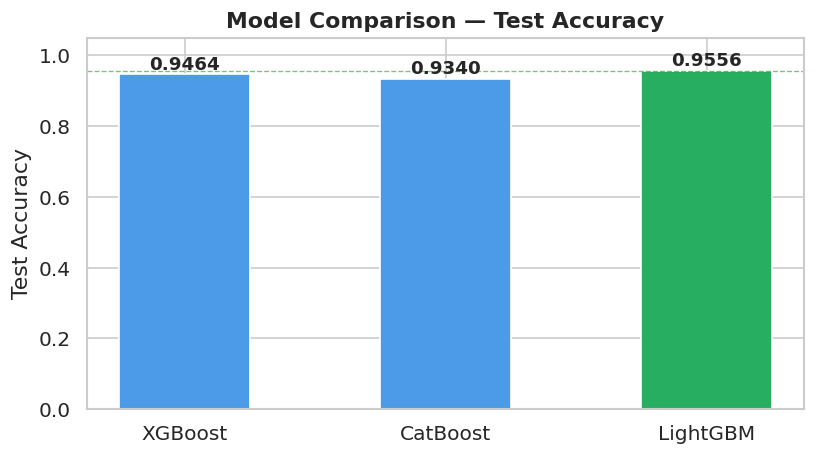

In [28]:
# accuracy comparison barchart
fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#27AE60" if n == best_model_name else "#4C9BE8" for n in results]
bars   = ax.bar(results.keys(), results.values(),
                color=colors, edgecolor="white", width=0.5)
 
for bar, (name, acc) in zip(bars, results.items()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f"{acc:.4f}", ha="center", va="bottom",
            fontsize=11, fontweight="bold")
 
ax.set_ylim(0, 1.05)
ax.set_ylabel("Test Accuracy")
ax.set_title("Model Comparison — Test Accuracy", fontweight="bold")
ax.axhline(y=max(results.values()), color="green",
           linestyle="--", linewidth=0.8, alpha=0.5)
plt.tight_layout()
plt.show()

In [29]:
#evaluation metrics
crop_names = [CROP_LABEL_DECODE[i] for i in sorted(CROP_LABEL_DECODE)]

# classification report for the 3 models
for name, y_pred in predictions.items():
    marker = " (BEST)" if name == best_model_name else ""
    print(f"  {name}{marker}")
    print(classification_report(y_test, y_pred, target_names=crop_names))



  XGBoost
              precision    recall  f1-score   support

Irish-potato       0.90      0.94      0.92       170
      Tomato       0.95      0.92      0.93       170
   Groundnut       1.00      1.00      1.00       170
      Pepper       0.95      0.89      0.92       170
     Cabbage       0.92      0.95      0.94       170
       Maize       0.88      0.93      0.91       170
       Wheat       0.95      0.96      0.96       170
   Pineapple       1.00      0.96      0.98       170
       Onion       0.96      0.96      0.96       170

    accuracy                           0.95      1530
   macro avg       0.95      0.95      0.95      1530
weighted avg       0.95      0.95      0.95      1530

  CatBoost
              precision    recall  f1-score   support

Irish-potato       0.90      0.91      0.90       170
      Tomato       0.95      0.92      0.93       170
   Groundnut       1.00      1.00      1.00       170
      Pepper       0.90      0.91      0.90       170
   

In [30]:
#Training and test score
# Training & Test Scores — All Models 
from sklearn.metrics import accuracy_score

print(" Training Score vs Test Score — All Models")

for name in trained:
    model = trained[name]

    train_pred  = model.predict(X_train_scaled)
    test_pred   = predictions[name]   # already stored from training cell

    train_score = accuracy_score(y_train, train_pred)
    test_score  = accuracy_score(y_test,  test_pred)
    difference  = train_score - test_score

    print(f"\n  {name}")
    print(f" Training Score : {train_score:.4f}  ({train_score*100:.2f}%)")
    print(f" Test Score : {test_score:.4f}  ({test_score*100:.2f}%)")
    print(f" Epochs : 300")
    print(f" Difference : {difference:.4f}", end="  ")

    if difference < 0.02:
        print("→ Excellent, no overfitting ✓")
    elif difference < 0.05:
        print("→ Slight overfitting, acceptable")
    else:
        print("→ Overfitting detected ✗")

 Training Score vs Test Score — All Models

  XGBoost
 Training Score : 1.0000  (100.00%)
 Test Score : 0.9464  (94.64%)
 Epochs : 300
 Difference : 0.0536  → Overfitting detected ✗

  CatBoost
 Training Score : 0.9755  (97.55%)
 Test Score : 0.9340  (93.40%)
 Epochs : 300
 Difference : 0.0415  → Slight overfitting, acceptable

  LightGBM
 Training Score : 1.0000  (100.00%)
 Test Score : 0.9556  (95.56%)
 Epochs : 300
 Difference : 0.0444  → Slight overfitting, acceptable


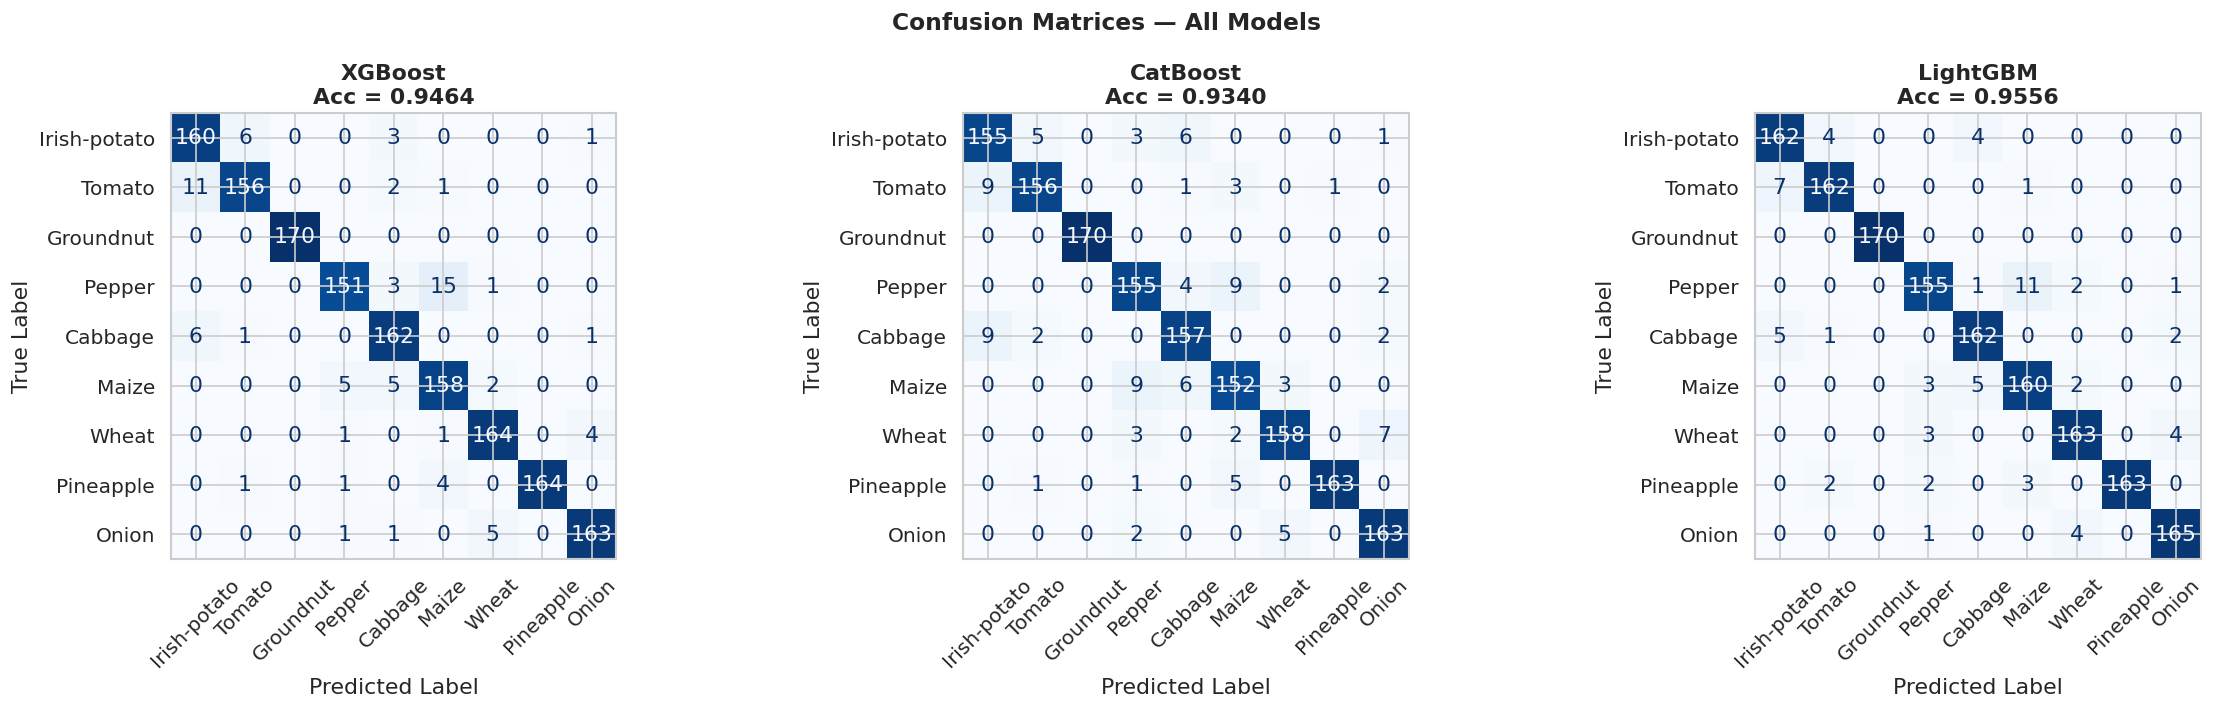

In [31]:
#Confusion metrics(side by side)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
 
for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm   = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=crop_names)
    disp.plot(ax=ax, colorbar=False, cmap="Blues", xticks_rotation=45)
    ax.set_title(f"{name}\nAcc = {results[name]:.4f}", fontweight="bold")
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
 
fig.suptitle("Confusion Matrices — All Models", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


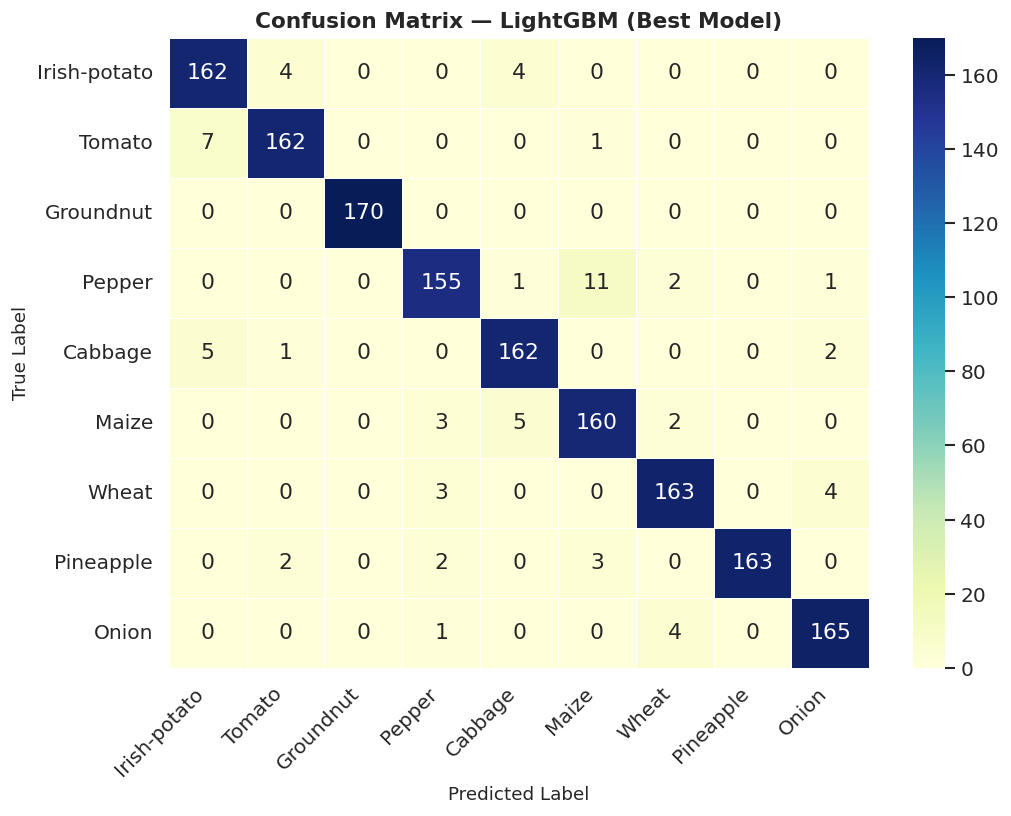

In [32]:
#Confusion metrics for da best model
best_pred = predictions[best_model_name]
cm_best   = confusion_matrix(y_test, best_pred)
 
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    cm_best, annot=True, fmt="d", cmap="YlGnBu",
    xticklabels=crop_names, yticklabels=crop_names,
    linewidths=0.4, ax=ax,
)
ax.set_xlabel("Predicted Label", fontsize=11)
ax.set_ylabel("True Label",      fontsize=11)
ax.set_title(f"Confusion Matrix — {best_model_name} (Best Model)",
             fontweight="bold", fontsize=13)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
 

In [33]:
#Model persistence and serializaton(save the results and other info) so that it does not hav to retrain everytime you give the program an input

best_model = trained[best_model_name]
 
artifacts = {
    MODELS_DIR / "best_model.pkl": best_model,
    MODELS_DIR / "scaler.pkl":     scaler,
    MODELS_DIR / "label_map.pkl":  {
        "encode": CROP_LABEL_MAP,
        "decode": CROP_LABEL_DECODE,
        "features": features,
        "best_model_name": best_model_name,
    },
}

print("\nSaving artifacts...")
for path, obj in artifacts.items():
    with open(path, "wb") as f:
        pickle.dump(obj, f)
    print(f"  Saved → {path}")
 
print("All artifacts saved successfully.")


Saving artifacts...
  Saved → saved_models/best_model.pkl
  Saved → saved_models/scaler.pkl
  Saved → saved_models/label_map.pkl
All artifacts saved successfully.


In [34]:
crop_data.head()

,LGA,Climate,Crop,pH,N,P,K,Temp,Rainfall,Salinity
0,Jos South,Highland,Irish-potato,4.72,95.98,59.12,223.93,11.18,559.03,1.38
1,Jos South,Highland,Irish-potato,4.94,84.39,57.28,119.64,10.37,642.34,0.22
2,Jos South,Highland,Irish-potato,3.00,81.14,30.06,160.47,8.82,352.85,1.32
3,Jos South,Highland,Irish-potato,4.14,103.18,30.00,115.39,12.39,398.58,0.74
4,Jos South,Highland,Irish-potato,3.83,90.61,37.25,225.00,11.95,414.90,0.98


In [35]:
#STEP 7: TEST RUN 

# Load saved artifacts
with open(MODELS_DIR / "best_model.pkl", "rb") as f:
    best_model = pickle.load(f)
with open(MODELS_DIR / "scaler.pkl", "rb") as f:
    scaler = pickle.load(f)
with open(MODELS_DIR / "label_map.pkl", "rb") as f:
    meta = pickle.load(f)

features   = meta["features"]
decode_map = meta["decode"]

# User inputs values
N  = 20 
P  = 10
K  = 10
pH  = 4.5
Temp =  18   
Rainfall = 1270
Salinity = 1.7 

#Predict crop 
user_input   = pd.DataFrame([[N, P, K, pH, Temp, Rainfall, Salinity]], columns=features)
input_scaled = scaler.transform(user_input)
pred_crop    = decode_map[best_model.predict(input_scaled)[0]]

#Find best-fit LGAs in Plateau State 
crop_cfg = CROP_CONFIG[pred_crop]

def lga_match_score(lga):
    climate = LGA_CLIMATE[lga]
    adj     = CLIMATE_ADJUSTMENTS[climate]
    bias    = LGA_SOIL_BIAS[lga]

    checks = {
        "Temp":     Temp,
        "Rainfall": Rainfall,
        "pH":       pH,
        "Salinity": Salinity,
    }
    score = 0
    for param, user_val in checks.items():
        adjusted_mean = crop_cfg[param]["mean"] + adj.get(param, 0) + bias.get(param, 0)
        lo = crop_cfg[param]["min"]
        hi = crop_cfg[param]["max"]
        if lo <= user_val <= hi:
            score += 1
        # bonus if user value is close to the LGA-adjusted mean
        if abs(user_val - adjusted_mean) <= crop_cfg[param]["std"]:
            score += 1
    return score

lga_scores = {lga: lga_match_score(lga) for lga in LGAs}
sorted_lgas = sorted(lga_scores, key=lga_scores.get, reverse=True)
top_lgas    = sorted_lgas[:3]

#  Results 
print(f"  RECOMMENDED CROP : {pred_crop.upper()}")
print("\n  Best LGAs in Plateau State:")
for rank, lga in enumerate(top_lgas, 1):
    climate = LGA_CLIMATE[lga]
    print(f" {rank}. {lga:<20} ({climate})")
print()

  RECOMMENDED CROP : GROUNDNUT

  Best LGAs in Plateau State:
 1. Jos South            (Highland)
 2. Kanke                (Lowland)
 3. Qua'an-Pan           (Lowland)



In [36]:
pip install shap

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Note: you may need to restart the kernel to use updated packages.


Running SHAP on best model: LightGBM
SHAP values shape: (1530, 7, 9)
Expected shape: (samples, features, classes) → (1530, 7, 9)
Feature importances (mean absolute SHAP):
  N            2.3621
  P            1.8612
  K            2.8988
  pH           0.7737
  Temp         1.0960
  Rainfall     1.5536
  Salinity     0.9097

Most important feature: K
Sample 5:
  True crop: Groundnut
  Predicted crop : Groundnut
  Match: ✓
  Input values:
    N            -1.586
    P            -0.963
    K            -1.127
    pH           0.839
    Temp         0.894
    Rainfall     0.908
    Salinity     -0.509
Sample 5:
  True crop: Groundnut
  Predicted crop: Groundnut
  Match: ✓
  Input values:
 N            -1.586
 P            -0.963
 K            -1.127
 pH           0.839
 Temp         0.894
 Rainfall     0.908
 Salinity     -0.509

Summary Plot


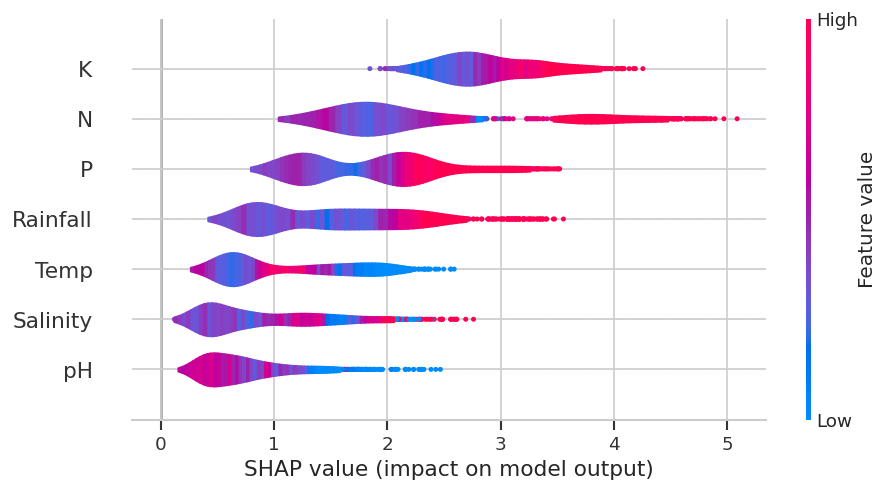


Bar Plot


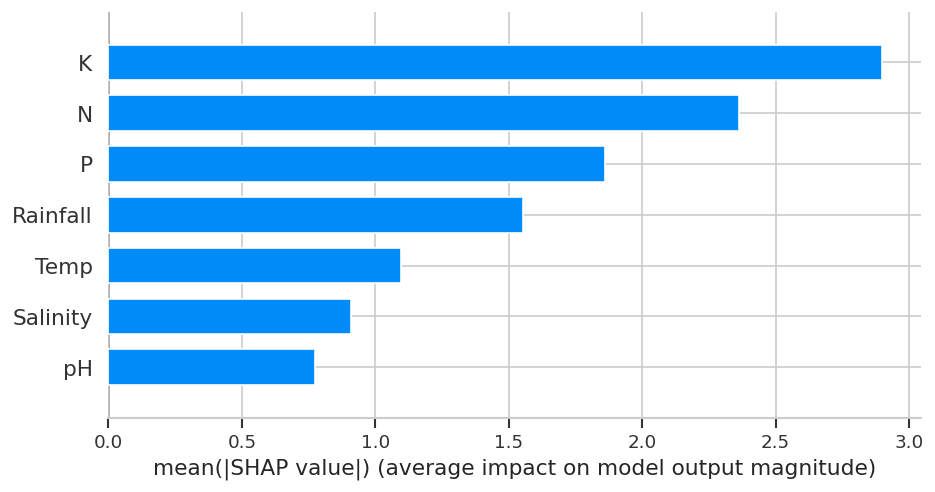


Waterfall Plot (single prediction explanation)
Explaining prediction for sample 0 → True crop: Cabbage


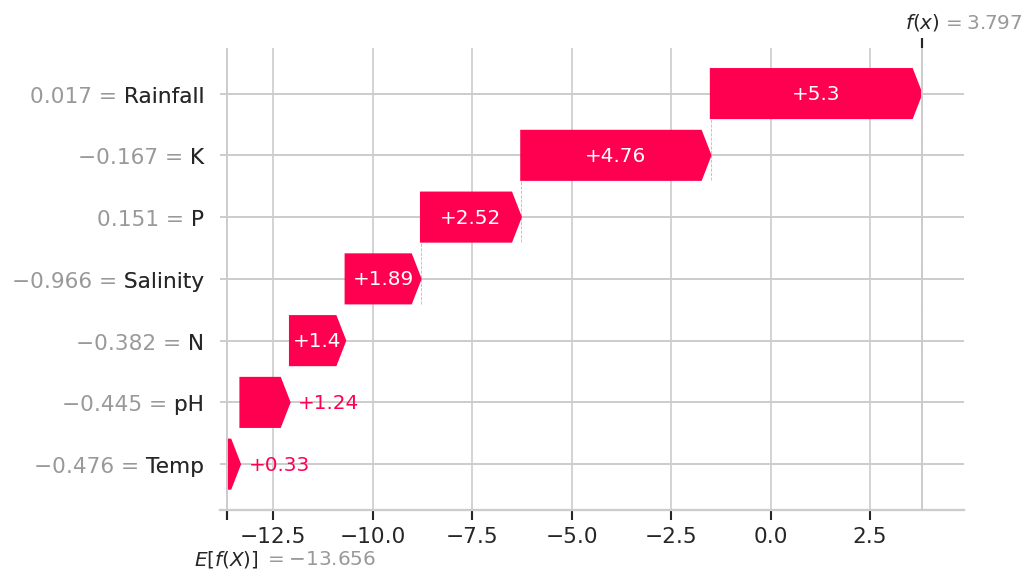

In [37]:
# SHAP EXPLAINABILITY 
import shap

print(f"Running SHAP on best model: {best_model_name}")

# this Create SHAP explainer 
explainer  = shap.TreeExplainer(trained[best_model_name])
shap_values = explainer.shap_values(X_test_scaled)


print("SHAP values shape:", np.array(shap_values).shape)
print("Expected shape: (samples, features, classes) →", 
      f"({X_test_scaled.shape[0]}, {len(features)}, {len(CROP_LABEL_MAP)})")

# Most important feature according to SHAP
mean_importance = np.abs(shap_values).mean(axis=(0, 2))  # average across samples and classes
most_important  = features[np.argmax(mean_importance)]

print("Feature importances (mean absolute SHAP):")
for feat, score in zip(features, mean_importance):
    print(f"  {feat:<12} {score:.4f}")

print(f"\nMost important feature: {most_important}")



# Pick a sample and check what the model predicted vs the truth
sample_idx  = 5   # change this to try different samples
true_label  = CROP_LABEL_DECODE[int(y_test.iloc[sample_idx])]
pred_label  = CROP_LABEL_DECODE[int(trained[best_model_name].predict(
                    X_test_scaled.iloc[[sample_idx]])[0])]

print(f"Sample {sample_idx}:")
print(f"  True crop: {true_label}")
print(f"  Predicted crop : {pred_label}")
print(f"  Match: {'✓' if true_label == pred_label else '✗ MISMATCH'}")
print(f"  Input values:")
for feat, val in zip(features, X_test_scaled.iloc[sample_idx]):
    print(f"    {feat:<12} {val:.3f}")
# Pick a sample and check what the model predicted vs the truth
sample_idx = 5   # change this to try different samples
true_label = CROP_LABEL_DECODE[int(y_test.iloc[sample_idx])]
pred_label = CROP_LABEL_DECODE[int(trained[best_model_name].predict(
                    X_test_scaled.iloc[[sample_idx]])[0])]

print(f"Sample {sample_idx}:")
print(f"  True crop: {true_label}")
print(f"  Predicted crop: {pred_label}")
print(f"  Match: {'✓' if true_label == pred_label else '✗ MISMATCH'}")
print(f"  Input values:")
for feat, val in zip(features, X_test_scaled.iloc[sample_idx]):
    print(f" {feat:<12} {val:.3f}")
    

# shap_values shape: (n_samples, n_features, n_classes)
# We average across all classes for a global feature importance view
shap_values_mean = np.abs(shap_values).mean(axis=2)  # shape: (n_samples, n_features)

# Plot 1: Summary Plot (feature impact across all predictions) 
print("\nSummary Plot")
shap.summary_plot(
    shap_values_mean,
    X_test_scaled,
    feature_names=features,
    plot_type="violin",
    show=True,
)

# Plot 2: Bar Plot (mean absolute SHAP — overall feature importance)
print("\nBar Plot")
shap.summary_plot(
    shap_values_mean,
    X_test_scaled,
    feature_names=features,
    plot_type="bar",
    show=True,
)

# ── Plot 3: Waterfall Plot (explains a single prediction)
# We pick the first test sample as our example
print("\nWaterfall Plot (single prediction explanation)")

sample_idx   = 0
sample_class = int(y_test.iloc[sample_idx])   # true class index
sample_name  = CROP_LABEL_DECODE[sample_class]

# Build a SHAP Explanation object for the true class of this sample
explanation = shap.Explanation(
    values    = shap_values[sample_idx, :, sample_class],
    base_values = explainer.expected_value[sample_class],
    data      = X_test_scaled.iloc[sample_idx].values,
    feature_names = features,
)

print(f"Explaining prediction for sample {sample_idx} → True crop: {sample_name}")
shap.plots.waterfall(explanation, show=True)